Number Cross
--
    
<img src='https://www.janestreet.com/puzzles/number_crossword_with_clues.png' width=800 align='center'/>



Place the digits 1 thru 9 (no zeroes) in the crossword grid below so that all of the clues are satisfied. No digit is repeated in any one grid entry (e.g. 1-across is a grid entry), and no grid entry is used more than once within the puzzle.

For your answer, submit the sum of the 8 5-digit grid entries in the completed grid (e.g. 4-down, 18-across, etc.)

In [2]:
import time
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
from pprint import pprint
from z3 import *

In [18]:
#which cells not to include
excluded = [{3, 7}, {3, 7}, {3}, {0, 1, 8, 9, 10}, {5}, {4, 5, 6}, {5}, {0, 1, 2, 9, 10}, {7}, {3, 7}, {3, 7}]

n = len(excluded)

gridshape = np.array([[0 if i not in excluded[j] else -1 for i in range(n)] for j in range(n)])

a_idx = [1, 4, 7, 10, 11, 12, 13, 14, 16, 18, 20, 24, 25, 26, 28, 29, 31, 34, 37, 38, 39, 40, 41, 42]
d_idx = [1, 18, 31, 2, 19, 32, 3, 33, 17, 4, 27, 5, 30, 6, 28, 15, 7, 21, 8, 22, 35, 9, 23, 36]

def build_dict(gridshape: np.array, d: dict, d_idx: list[int], rev = False) -> None:
    k = 0
    temp = []
    for j in range(len(gridshape) + 1):
        if temp:
            d[d_idx[k]] = temp
            temp = []
            k += 1
            
        if j == n:
            break
            
        for i in range(len(gridshape[j])):
            if gridshape[j][i] != -1:
                if rev:
                    temp.append((i, j))
                else:
                    temp.append((j, i))
    
            else:
                if temp:
                    d[d_idx[k]] = temp
                    temp = []
                    k += 1

a = {}
d = {}

build_dict(gridshape, a, a_idx)
build_dict(gridshape.T, d, d_idx, rev = True)

In [53]:
#Looks at individual digits to return the full number
def dig2num(word):
    l = len(word)
    return Sum([num * 10 ** (l - i - 1) for i, num in enumerate(word)])

def digsum(word):
    return Sum([digit for digit in word])

#All prime numbers between bounds
def _primes(ceiling: int, floor: int) -> list[int]:
    lst = [2]
    check = False
    for i in range(3, ceiling, 2):
        for num in lst:
            if i % num == 0:
                check = False
                break
                
            else:
                check = True
                
        if check == True:
            lst.append(i)

    lst = [i for i in lst if i > floor]
    return lst

#Basic grid setup
grid = np.array([[Int(f"X_{[j,i]}") for i in range(n)] for j in range(n)])
s = Tactic("qffd").solver()

#Force the zeroes in the black squares
[[s.add(grid[j][i] == 0) for i in range(n) if i in excluded[j]] for j in range(n)]

#Bind cell values between 1 and 9 inclusive
[[s.add(grid[j][i] < 10, grid[j][i] > 0) for i in range(n) if i not in excluded[j]] for j in range(n)]

#Add distinct clauses
words = [[grid[i] for i in v] for k, v in a.items()] + [[grid[i] for i in v] for k, v in d.items()]
[s.add(Distinct([x for x in i])) for i in words]

lst = []
for word in words:
    lst.append(dig2num(word))

s.add(Distinct(lst))

#Create accessable word dictionary for words to constrain clues
d_k = [f"a{i}" for i in a_idx] + [f"d{i}" for i in d_idx]
d_w = {item: word for item, word in zip(d_k, words)}

#Squares are bounded between 10 and 31 inclusive
squares = [i*i for i in range(10,32)]
#a1
s.add(Or([dig2num(d_w["a1"]) == i for i in squares]))
#a4
s.add(Or([dig2num(d_w["a4"]) == i for i in squares]))
#a7
s.add(Or([dig2num(d_w["a7"]) == i for i in squares]))
#a11
s.add(Or([dig2num(d_w["a11"]) == i for i in squares]))
#a12
s.add(Or([dig2num(d_w["a12"]) == i for i in squares]))

#-----

#d1
s.add(Or([dig2num(d_w["d1"]) == i for i in squares]))
#d7
s.add(Or([dig2num(d_w["d7"]) == i for i in squares]))
#d8
s.add(Or([dig2num(d_w["d8"]) == i for i in squares]))
#d18
s.add(Or([dig2num(d_w["d18"]) == i for i in squares]))
#d19
s.add(Or([dig2num(d_w["d19"]) == i for i in squares]))
#d36
s.add(Or([dig2num(d_w["d36"]) == i for i in squares]))

#Primes
primes = _primes(1000,100)
#a39
s.add(Or([dig2num(d_w["a39"]) == 2*i for i in primes if i < 500]))
#a9
s.add(Or([dig2num(d_w["d9"]) == i for i in primes]))
#a22
s.add(Or([dig2num(d_w["d22"]) == i for i in primes]))

#Relative to others
#a10
s.add(dig2num(d_w["a10"]) < dig2num(d_w["d23"]))
#a13
for word in words:
    s.add(dig2num(d_w["a13"]) <= dig2num(word))
#a18
s.add(dig2num(d_w["a18"]) == dig2num(d_w["a37"]) + dig2num(d_w["d6"]))
#20
temp = d_w["a20"]
r_temp = temp[::-1]
for word in words:
    if len(word) == 5:
        s.add(dig2num(temp) >= dig2num(word))
        s.add(dig2num(r_temp) >= dig2num(word))
#a25
s.add(dig2num(d_w["a25"]) == dig2num(d_w["a42"]) + dig2num(d_w["d7"]))
#a29
s.add(dig2num(d_w["a29"]) == dig2num(d_w["a4"]) * dig2num(d_w["d35"]))
#a38
s.add(dig2num(d_w["a38"]) == dig2num(d_w["a39"]) - dig2num(d_w["a13"]))
#a40
s.add(dig2num(d_w["a40"]) > dig2num(d_w["a1"]))

#-----

#d3
for word in words:
    s.add(dig2num(d_w["d3"]) >= dig2num(word))
#d23
s.add(dig2num(d_w["d23"]) > dig2num(d_w["d32"]))
#d27
s.add(dig2num(d_w["d6"]) == 2*dig2num(d_w["d27"]))


#Divisibles & Multiples
#a16
s.add(dig2num(d_w["a16"]) % 6 == 0)
#a31
s.add(dig2num(d_w["a31"]) % 3 == 0)
#a34
s.add(dig2num(d_w["a34"]) % 3 == 0)
#a41
s.add(dig2num(d_w["a41"]) % 25 == 0)
#a42
s.add(dig2num(d_w["a42"]) % 2 != 0)

#-----

#d2
s.add(dig2num(d_w["d2"]) % 11 == 0)
#d5
s.add(Or([dig2num(d_w["d5"]) == dig2num(d_w["d9"]) * n for n in range(1,11)]))
#d15
s.add(dig2num(d_w["d15"]) % 11 == 0)
#d17
s.add(dig2num(d_w["d17"]) % 9 == 0)
#d28
s.add(dig2num(d_w["d28"]) % 125 == 0)
#d32
s.add(Or([dig2num(d_w["d32"]) == dig2num(d_w["d31"]) * n for n in range(1,10)]))
#d33
s.add(Or([dig2num(d_w["d33"]) == dig2num(d_w["d31"]) * n for n in range(1,10)]))
#d35
s.add(dig2num(d_w["d35"]) % 2 == 0)

#Ascending / Descending
#a28
word = d_w["a28"]
for i in range(len(word) - 1):
    s.add(word[i + 1] > word[i])
#a37
word = d_w["a37"]
for i in range(len(word) - 1):
    s.add(word[i + 1] > word[i])
    
#-----

#d30
word = d_w["d30"]
for i in range(len(word) - 1):
    s.add(word[i + 1] < word[i])

#Digit sums
#d4
s.add(digsum(d_w["d4"]) == 16)
#d6
s.add(digsum(d_w["d6"]) == 35)
#a14
s.add(digsum(d_w["a14"]) == 42)
#d21
s.add(digsum(d_w["d21"]) == 41)
#a26
s.add(digsum(d_w["a26"]) == 26)
#d31
s.add(digsum(d_w["d31"]) == 6)

#Other
#a24
word = d_w["a24"]
for d1 in word:
    s.add(Or([d1 == d2 for d2 in d_w["d5"]]))

start = time.perf_counter()
if s.check() == sat:
    m = s.model()
    sol = np.array([[m[cell].as_long() if cell != None else -1 for cell in row] for row in grid])
    print(sol)

end = time.perf_counter()
print(f"Time elapsed is {(end - start):.2f} seconds")

[[3 2 4 0 2 5 6 0 5 2 9]
 [6 5 9 0 1 6 9 0 7 8 4]
 [1 3 2 0 4 8 5 3 6 9 7]
 [0 0 1 3 6 2 7 8 0 0 0]
 [6 9 7 1 3 0 8 7 2 1 9]
 [2 6 5 8 0 0 0 1 4 3 7]
 [5 1 8 9 3 0 3 4 5 7 8]
 [0 0 0 2 4 9 8 5 6 0 0]
 [2 6 8 4 7 5 1 0 7 9 8]
 [1 3 5 0 8 4 2 0 9 7 4]
 [3 9 2 0 9 2 5 0 8 6 1]]
Time elapsed is 1.98 seconds


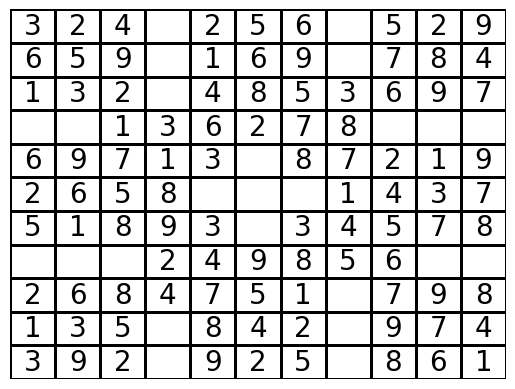

<Figure size 1000x1000 with 0 Axes>

In [54]:
def grid_plotter(array: np.array) -> None:
    mask = array == 0
    ax = sns.heatmap(
        array, mask = mask, cmap=ListedColormap(['white']), annot=True, annot_kws={"fontsize":20, "color":"black"}, cbar=False, linewidths=1, linecolor="black",
        xticklabels = False, yticklabels = False
    )
    plt.figure(figsize = (10,10))
    plt.show()

grid_plotter(sol)

In [66]:
solution = [sol[0:5, 4], sol[0:5, 6], sol[6:11, 4], sol[6:11, 6], sol[4, 0:5], sol[4, 6:11], sol[6, 0:5], sol[6, 6:11]]
solution = map(dig2num, solution)
print(sum(list(solution)))

407358
